# ARG-BERT Mini Practical — Fast Resource-Constrained Reproduction

**Based on:** Yagimoto et al., *Prediction of antibiotic resistance mechanisms using a protein language model* (Bioinformatics, 2024)

## Goal

This notebook is a **small, runnable proof-of-concept** designed for limited hardware and limited time.

Instead of reproducing the paper's full 5-fold ProteinBERT fine-tuning on thousands of proteins, it:

1. uses a small stratified subset of the CARD-derived dataset;
2. extracts **pretrained ProteinBERT whole-protein embeddings**;
3. trains a very small multiclass Logistic Regression classifier on those embeddings;
4. compares it with a lightweight amino-acid 3-mer baseline;
5. reports Accuracy, macro Precision, macro Recall, and macro F1;
6. implements a lightweight creative extension: **confidence-aware selective prediction**;
7. optionally examines whether model confidence is related to proximity in ProteinBERT embedding space.

This is **not an exact numerical reproduction** of the paper. It is a resource-constrained implementation that preserves the core idea of using a pretrained protein language model for resistance-mechanism prediction.

### Expected practical runtime
- Mini dataset preparation: seconds.
- 3-mer baseline: seconds.
- ProteinBERT weight download: one-time download (~192 MB).
- ProteinBERT embedding extraction for ~150–200 proteins: typically the main compute step, but far lighter than fine-tuning.
- Logistic Regression + creative extension: seconds.

The notebook is intended to run on a 4 GB RTX 3050 or similar GPU.

## 1. Why this shortcut is scientifically reasonable

The original ARG-BERT paper fine-tunes ProteinBERT end-to-end.  
For a fast implementation, we freeze the pretrained ProteinBERT and use its **global protein representation as a feature vector**.

The official ProteinBERT project explicitly supports extracting whole-sequence embeddings and using them as features for downstream machine-learning models.

Therefore, the mini experiment keeps the important idea:

**protein sequence → pretrained ProteinBERT representation → resistance-mechanism classifier**

while avoiding expensive end-to-end fine-tuning.

In [1]:
import sys
print(sys.version)
print(sys.executable)

3.10.8 | packaged by conda-forge | (main, Nov 22 2022, 08:16:53) [MSC v.1929 64 bit (AMD64)]
c:\Users\user\anaconda3\envs\tf\python.exe


In [4]:
%pip install tensorflow==2.10.0 numpy==1.23.5

  Using cached numpy-1.23.5-cp310-cp310-win_amd64.whl.metadata (2.3 kB)
  Using cached Keras_Preprocessing-1.1.2-py2.py3-none-any.whl.metadata (1.9 kB)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached protobuf-3.19.6-cp310-cp310-win_amd64.whl.metadata (806 bytes)
  Using cached tensorflow_io_gcs_filesystem-0.31.0-cp310-cp310-win_amd64.whl.metadata (14 kB)
   ---------------------------------------- 0.0/14.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.6 MB ? eta -:--:--
    --------------------------------------- 0.3/14.6 MB ? eta -:--:--
   - -------------------------------------- 0.5/14.6 MB 2.4 MB/s eta 0:00:06
   -- ------------------------------------- 1.0/14.6 MB 1.8 MB/s eta 0:00:08
   -- ------------------------------------- 1.0/14.6 MB 1.8 MB/s eta 0:00:08
   -- -------------

In [2]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.10.0
GPU: []


In [3]:
# Core configuration
from pathlib import Path
import os, sys, json, random, warnings
import numpy as np
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd()
DATASET_PATH = PROJECT_ROOT / "data" / "card_argbert_master.csv"
ARG_BERT_REPO = PROJECT_ROOT / "vendor" / "ARG-BERT"
OUT_DIR = PROJECT_ROOT / "mini_outputs"
OUT_DIR.mkdir(exist_ok=True)

# Small experiment size.
N_PER_CORE_CLASS = 30
MAX_OTHERS = 9

# Keep the same six labels as the paper.
LABELS = [
    "antibiotic efflux",
    "antibiotic inactivation",
    "antibiotic target alteration",
    "antibiotic target protection",
    "antibiotic target replacement",
    "others",
]

# Restrict to proteins that fit comfortably in a short ProteinBERT input.
MAX_SEQUENCE_LENGTH = 510
PBERT_SEQUENCE_LENGTH = 512
PBERT_BATCH_SIZE = 8

print("Dataset:", DATASET_PATH)
print("Official ARG-BERT repo:", ARG_BERT_REPO)
print("Output directory:", OUT_DIR)

Dataset: c:\Users\user\Desktop\Term6\CDD\ARG_BERT_CARD_Phase2_Final\data\card_argbert_master.csv
Official ARG-BERT repo: c:\Users\user\Desktop\Term6\CDD\ARG_BERT_CARD_Phase2_Final\vendor\ARG-BERT
Output directory: c:\Users\user\Desktop\Term6\CDD\ARG_BERT_CARD_Phase2_Final\mini_outputs


## 2. Load the CARD-derived dataset

This notebook expects the dataset already produced by the full project:

`data/card_argbert_master.csv`

If the file is missing, run the two lightweight preprocessing scripts from the full project once:

```bash
python3 scripts/00_download_card.py
python3 scripts/01_build_card_dataset.py
```

The CARD download is small compared with ProteinBERT training.

In [4]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"{DATASET_PATH} was not found. Run scripts/00_download_card.py and "
        "scripts/01_build_card_dataset.py once, then rerun this notebook."
    )

df = pd.read_csv(DATASET_PATH)

required_cols = {"sequence", "mechanism"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Dataset is missing required columns: {missing}")

df = df[df["mechanism"].isin(LABELS)].copy()
df = df[df["sequence"].str.len() <= MAX_SEQUENCE_LENGTH].copy()

print("Available proteins after length filtering:", len(df))
display(df["mechanism"].value_counts().rename("available_count").to_frame())

Available proteins after length filtering: 5809


,available_count
mechanism,
antibiotic inactivation,5239
antibiotic efflux,206
antibiotic target alteration,164
antibiotic target protection,127
antibiotic target replacement,65
others,8


## 3. Build a tiny stratified dataset

To make the experiment fast, we use:
- up to **30 proteins per core mechanism**;
- all available `others` proteins, up to 9.

This normally produces roughly 150–160 proteins.

`others` is extremely rare in the CARD-derived PHM dataset, so its test-set estimate will be noisy.  
This limitation should be explicitly reported.

In [5]:
parts = []

for label in LABELS:
    group = df[df["mechanism"] == label]
    if label == "others":
        n = min(MAX_OTHERS, len(group))
    else:
        n = min(N_PER_CORE_CLASS, len(group))
    parts.append(group.sample(n=n, random_state=SEED))

mini_df = (
    pd.concat(parts, ignore_index=True)
    .sample(frac=1.0, random_state=SEED)
    .reset_index(drop=True)
)

mini_df.to_csv(OUT_DIR / "mini_dataset.csv", index=False)

print("Mini dataset size:", len(mini_df))
display(mini_df["mechanism"].value_counts().rename("count").to_frame())

Mini dataset size: 158


,count
mechanism,
antibiotic target replacement,30
antibiotic inactivation,30
antibiotic target protection,30
antibiotic efflux,30
antibiotic target alteration,30
others,8


## 4. Train/test split

In [6]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    mini_df,
    test_size=0.25,
    random_state=SEED,
    stratify=mini_df["mechanism"],
)

print("Train:", len(train_df))
print("Test :", len(test_df))

display(
    pd.DataFrame({
        "train": train_df["mechanism"].value_counts(),
        "test": test_df["mechanism"].value_counts(),
    }).fillna(0).astype(int)
)

Train: 118
Test : 40


,train,test
mechanism,,
antibiotic efflux,22,8
antibiotic inactivation,23,7
antibiotic target alteration,22,8
antibiotic target protection,22,8
antibiotic target replacement,23,7
others,6,2


# Part A — Very fast sequence baseline

Before ProteinBERT, we create a simple amino-acid **3-mer TF-IDF + Logistic Regression** baseline.

This gives us a useful comparison:
- handcrafted/local sequence statistics;
- pretrained protein-language-model representation.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

kmer_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            analyzer="char",
            ngram_range=(3, 3),
            lowercase=False,
            min_df=1,
            max_features=12000,
        ),
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=SEED,
        ),
    ),
])

kmer_model.fit(train_df["sequence"], train_df["mechanism"])
kmer_pred = kmer_model.predict(test_df["sequence"])
kmer_prob = kmer_model.predict_proba(test_df["sequence"])

print("3-mer baseline trained.")

3-mer baseline trained.


## 5. Evaluate the 3-mer baseline

In [8]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

def evaluate_predictions(y_true, y_pred, model_name):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
    }

results = []

kmer_metrics = evaluate_predictions(
    test_df["mechanism"],
    kmer_pred,
    "AA 3-mer TF-IDF + Logistic Regression",
)
results.append(kmer_metrics)

display(pd.DataFrame([kmer_metrics]).round(4))

print(
    classification_report(
        test_df["mechanism"],
        kmer_pred,
        labels=LABELS,
        zero_division=0,
    )
)

,model,accuracy,macro_precision,macro_recall,macro_f1
0,AA 3-mer TF-IDF + Logistic Regression,0.725,0.687,0.631,0.6245


                               precision    recall  f1-score   support

            antibiotic efflux       0.54      0.88      0.67         8
      antibiotic inactivation       1.00      0.86      0.92         7
 antibiotic target alteration       0.58      0.88      0.70         8
 antibiotic target protection       1.00      0.75      0.86         8
antibiotic target replacement       1.00      0.43      0.60         7
                       others       0.00      0.00      0.00         2

                     accuracy                           0.72        40
                    macro avg       0.69      0.63      0.62        40
                 weighted avg       0.77      0.72      0.71        40



# Part B — ProteinBERT shortcut

## 6. Load the official ProteinBERT code

The notebook first tries to use the `proteinbert/` code already present in the downloaded ARG-BERT repository.

Expected structure:

`vendor/ARG-BERT/proteinbert/`

This avoids reinstalling or cloning another repository.

In [9]:
if not ARG_BERT_REPO.exists():
    raise FileNotFoundError(
        "vendor/ARG-BERT was not found. Put the official ARG-BERT repository "
        "inside vendor/ARG-BERT before running the ProteinBERT section."
    )

sys.path.insert(0, str(ARG_BERT_REPO))

from proteinbert.existing_model_loading import load_pretrained_model
from proteinbert.conv_and_global_attention_model import (
    get_model_with_hidden_layers_as_outputs,
)

print("ProteinBERT code imported from:", ARG_BERT_REPO)

ProteinBERT code imported from: c:\Users\user\Desktop\Term6\CDD\ARG_BERT_CARD_Phase2_Final\vendor\ARG-BERT


## 7. Download the pretrained ProteinBERT weights once

The original ProteinBERT project provides the pretrained model snapshot publicly.

This cell downloads the ~192 MB Zenodo snapshot only if it is not already present.

If the download is interrupted, rerun the cell; the notebook stores the model locally under `mini_pbert_weights/`.

In [10]:
import requests

WEIGHTS_DIR = PROJECT_ROOT / "mini_pbert_weights"
WEIGHTS_DIR.mkdir(exist_ok=True)

WEIGHTS_FILE = WEIGHTS_DIR / "default.pkl"
ZENODO_URL = (
    "https://zenodo.org/records/10371965/files/"
    "full_go_epoch_92400_sample_23500000.pkl?download=1"
)

def download_file(url, path, chunk_mb=4):
    if path.exists() and path.stat().st_size > 100_000_000:
        print("Pretrained weights already exist:", path)
        return

    temp_path = path.with_suffix(".part")
    headers = {}
    existing = temp_path.stat().st_size if temp_path.exists() else 0
    if existing:
        headers["Range"] = f"bytes={existing}-"
        print(f"Resuming from {existing / 1024**2:.1f} MB")

    with requests.get(url, stream=True, timeout=120, headers=headers) as r:
        # If the server ignores Range, restart cleanly.
        if existing and r.status_code == 200:
            existing = 0
            temp_path.unlink(missing_ok=True)

        r.raise_for_status()
        mode = "ab" if existing else "wb"
        with temp_path.open(mode) as f:
            for chunk in r.iter_content(chunk_size=chunk_mb * 1024 * 1024):
                if chunk:
                    f.write(chunk)

    temp_path.replace(path)
    print("Downloaded:", path, f"({path.stat().st_size / 1024**2:.1f} MB)")

download_file(ZENODO_URL, WEIGHTS_FILE)

ConnectionError: HTTPSConnectionPool(host='zenodo.org', port=443): Read timed out.

## 8. Extract pretrained whole-protein embeddings

This is the main shortcut.

We do **not** fine-tune ProteinBERT.  
We run a forward pass and retain its global protein representation.

The official ProteinBERT documentation explicitly supports this use.

In [11]:
import tensorflow as tf

# Avoid TensorFlow reserving all GPU memory at once.
gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception:
        pass

print("TensorFlow GPUs:", gpus)

pretrained_model_generator, input_encoder = load_pretrained_model(
    local_model_dump_dir=str(WEIGHTS_DIR),
    local_model_dump_file_name="default.pkl",
    download_model_dump_if_not_exists=False,
    validate_downloading=False,
)

embedding_model = get_model_with_hidden_layers_as_outputs(
    pretrained_model_generator.create_model(PBERT_SEQUENCE_LENGTH)
)

def proteinbert_embeddings(sequences, batch_size=PBERT_BATCH_SIZE):
    sequences = list(sequences)
    encoded_x = input_encoder.encode_X(
        sequences,
        PBERT_SEQUENCE_LENGTH,
    )
    local_repr, global_repr = embedding_model.predict(
        encoded_x,
        batch_size=batch_size,
        verbose=1,
    )
    global_repr = np.asarray(global_repr)
    return global_repr.reshape(len(sequences), -1)

X_train_pbert = proteinbert_embeddings(train_df["sequence"])
X_test_pbert = proteinbert_embeddings(test_df["sequence"])

print("Train embedding shape:", X_train_pbert.shape)
print("Test embedding shape :", X_test_pbert.shape)

np.save(OUT_DIR / "X_train_pbert.npy", X_train_pbert)
np.save(OUT_DIR / "X_test_pbert.npy", X_test_pbert)

TensorFlow GPUs: []
c:\Users\user\Desktop\Term6\CDD\ARG_BERT_CARD_Phase2_Final\mini_pbert_weights\default.pkl
5/5 [==============================] - 0s 89ms/step
Train embedding shape: (118, 15599)
Test embedding shape : (40, 15599)


## 9. Train a tiny classifier on frozen ProteinBERT embeddings

Only the Logistic Regression classifier is trained.

This takes seconds and avoids expensive end-to-end ProteinBERT fine-tuning.

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

pbert_classifier = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=SEED,
    ),
)

pbert_classifier.fit(X_train_pbert, train_df["mechanism"])

pbert_pred = pbert_classifier.predict(X_test_pbert)
pbert_prob = pbert_classifier.predict_proba(X_test_pbert)

print("ProteinBERT embedding classifier trained.")

ProteinBERT embedding classifier trained.


## 10. ProteinBERT mini-results

In [13]:
pbert_metrics = evaluate_predictions(
    test_df["mechanism"],
    pbert_pred,
    "Frozen ProteinBERT embeddings + Logistic Regression",
)
results.append(pbert_metrics)

results_df = pd.DataFrame(results)
display(results_df.round(4))

print(
    classification_report(
        test_df["mechanism"],
        pbert_pred,
        labels=LABELS,
        zero_division=0,
    )
)

results_df.to_csv(OUT_DIR / "mini_results_summary.csv", index=False)

,model,accuracy,macro_precision,macro_recall,macro_f1
0,AA 3-mer TF-IDF + Logistic Regression,0.725,0.6870,0.6310,0.6245
1,Frozen ProteinBERT embeddings + Logistic Regre...,0.825,0.7857,0.7857,0.7796


                               precision    recall  f1-score   support

            antibiotic efflux       0.67      0.75      0.71         8
      antibiotic inactivation       0.86      0.86      0.86         7
 antibiotic target alteration       1.00      0.75      0.86         8
 antibiotic target protection       1.00      1.00      1.00         8
antibiotic target replacement       0.86      0.86      0.86         7
                       others       0.33      0.50      0.40         2

                     accuracy                           0.82        40
                    macro avg       0.79      0.79      0.78        40
                 weighted avg       0.85      0.82      0.83        40



## 11. Confusion matrix

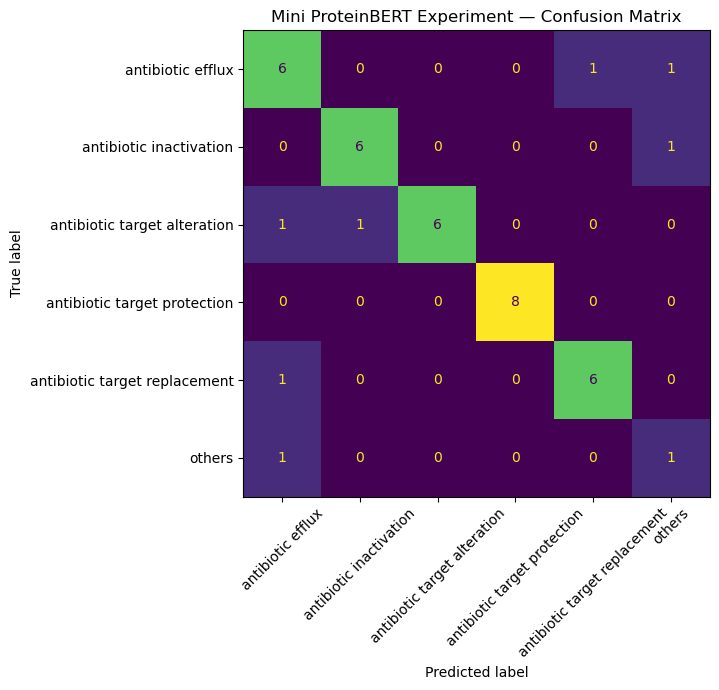

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay.from_predictions(
    test_df["mechanism"],
    pbert_pred,
    labels=LABELS,
    xticks_rotation=45,
    ax=ax,
    colorbar=False,
)
ax.set_title("Mini ProteinBERT Experiment — Confusion Matrix")
plt.tight_layout()
plt.savefig(OUT_DIR / "pbert_confusion_matrix.png", dpi=200)
plt.show()

# Part C — Lightweight creative extension

## 12. Confidence-aware selective prediction

The creative idea is simplified to make it runnable in seconds.

Instead of forcing the model to predict every protein, the model can **abstain** on uncertain predictions.

For example:
- 100% coverage: predict every test protein.
- 80% coverage: keep only the 80% most confident predictions.
- 60% coverage: keep only the 60% most confident predictions.

If accuracy improves as coverage decreases, uncertainty can be used as a practical screening mechanism.

This is a lightweight version of the larger calibrated selective ARG-BERT idea.

In [15]:
# Match predict_proba columns to classifier classes.
classes = pbert_classifier.named_steps["logisticregression"].classes_

confidence = pbert_prob.max(axis=1)
confidence_pred = classes[pbert_prob.argmax(axis=1)]
y_true = test_df["mechanism"].to_numpy()

order = np.argsort(-confidence)

rows = []
for coverage in [1.0, 0.9, 0.8, 0.7, 0.6, 0.5]:
    n_keep = max(1, int(np.ceil(len(y_true) * coverage)))
    keep = order[:n_keep]

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true[keep],
        confidence_pred[keep],
        average="macro",
        zero_division=0,
    )

    rows.append({
        "coverage": n_keep / len(y_true),
        "n_retained": n_keep,
        "accuracy": accuracy_score(y_true[keep], confidence_pred[keep]),
        "macro_f1": f1,
        "mean_confidence": confidence[keep].mean(),
    })

selective_df = pd.DataFrame(rows)
display(selective_df.round(4))
selective_df.to_csv(OUT_DIR / "selective_prediction.csv", index=False)

,coverage,n_retained,accuracy,macro_f1,mean_confidence
0,1.0,40,0.8250,0.7796,0.9998
1,0.9,36,0.8611,0.8158,0.9999
2,0.8,32,0.8438,0.8078,0.9999
3,0.7,28,0.8214,0.7348,0.9999
4,0.6,24,0.7917,0.7056,1.0000
5,0.5,20,0.7500,0.5833,1.0000


## 13. Plot accuracy versus retained coverage

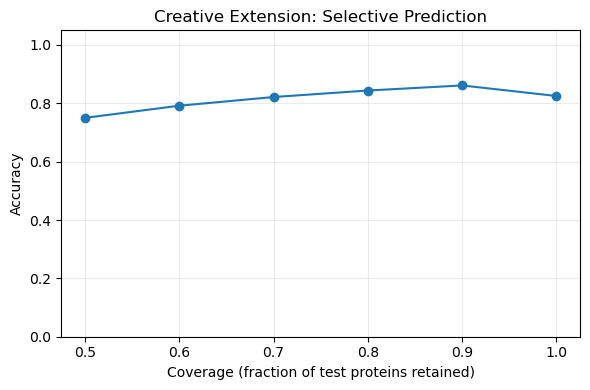

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(
    selective_df["coverage"],
    selective_df["accuracy"],
    marker="o",
)
ax.set_xlabel("Coverage (fraction of test proteins retained)")
ax.set_ylabel("Accuracy")
ax.set_title("Creative Extension: Selective Prediction")
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_DIR / "selective_accuracy_vs_coverage.png", dpi=200)
plt.show()

## 14. Lightweight familiarity analysis

The full creative idea uses sequence homology.  
To keep this mini notebook fast, we use **maximum cosine similarity in ProteinBERT embedding space** as a lightweight familiarity score.

This is **not sequence identity** and must not be called true homology.

Question:

> Are proteins that look more familiar in ProteinBERT representation space also predicted with higher confidence?

In [17]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import spearmanr

similarity_matrix = cosine_similarity(X_test_pbert, X_train_pbert)
max_embedding_similarity = similarity_matrix.max(axis=1)

rho, p_value = spearmanr(max_embedding_similarity, confidence)

familiarity_df = pd.DataFrame({
    "true_label": y_true,
    "predicted_label": confidence_pred,
    "confidence": confidence,
    "max_train_embedding_similarity": max_embedding_similarity,
    "correct": (y_true == confidence_pred).astype(int),
})

familiarity_df.to_csv(OUT_DIR / "familiarity_analysis.csv", index=False)

print(f"Spearman rho = {rho:.4f}")
print(f"P-value      = {p_value:.4g}")
display(familiarity_df.head())

Spearman rho = 0.0727
P-value      = 0.6556


,true_label,predicted_label,confidence,max_train_embedding_similarity,correct
0,antibiotic target alteration,antibiotic target alteration,0.999584,0.862243,1
1,antibiotic inactivation,antibiotic inactivation,0.999977,0.746118,1
2,antibiotic target alteration,antibiotic target alteration,0.999940,0.885039,1
3,antibiotic target replacement,antibiotic target replacement,1.000000,0.953358,1
4,antibiotic efflux,antibiotic efflux,0.999175,0.671798,1


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(
    familiarity_df["max_train_embedding_similarity"],
    familiarity_df["confidence"],
    alpha=0.75,
)
ax.set_xlabel("Max cosine similarity to a training ProteinBERT embedding")
ax.set_ylabel("Prediction confidence")
ax.set_title("Embedding Familiarity vs Confidence")
plt.tight_layout()
plt.savefig(OUT_DIR / "familiarity_vs_confidence.png", dpi=200)
plt.show()

# 15. Final compact results table

This cell produces one table that can be copied directly into the project report.

The values are **your actual mini-experiment results** after the notebook is run.

In [18]:
final_table = results_df.copy()

paper_reference = pd.DataFrame([
    {
        "model": "Paper ARG-BERT — HMD-ARG DB (published reference)",
        "accuracy": 0.999,
        "macro_precision": 0.943,
        "macro_recall": 0.934,
        "macro_f1": 0.937,
    },
    {
        "model": "Paper ARG-BERT — Low Homology (published reference)",
        "accuracy": 0.927,
        "macro_precision": 0.869,
        "macro_recall": 0.871,
        "macro_f1": 0.866,
    },
])

comparison_table = pd.concat(
    [final_table, paper_reference],
    ignore_index=True,
)

display(comparison_table.round(4))
comparison_table.to_csv(OUT_DIR / "comparison_with_paper.csv", index=False)

,model,accuracy,macro_precision,macro_recall,macro_f1
0,AA 3-mer TF-IDF + Logistic Regression,0.725,0.6870,0.6310,0.6245
1,Frozen ProteinBERT embeddings + Logistic Regre...,0.825,0.7857,0.7857,0.7796
2,Paper ARG-BERT — HMD-ARG DB (published reference),0.999,0.9430,0.9340,0.9370
3,Paper ARG-BERT — Low Homology (published refer...,0.927,0.8690,0.8710,0.8660




## Mini implementation

> Due to limited local GPU memory and time, a resource-constrained reproduction was performed instead of full end-to-end five-fold fine-tuning. A small stratified CARD-derived dataset was used. Pretrained ProteinBERT global representations were extracted and frozen, and a lightweight multiclass Logistic Regression classifier was trained on top of them. This preserves the main protein-language-model representation idea while substantially reducing computational cost.

## Baseline

> A character-level amino-acid 3-mer TF-IDF Logistic Regression model was used as a fast sequence baseline.

## Creative extension

> A confidence-aware selective prediction strategy was implemented. The model was allowed to abstain on its least confident predictions, and accuracy was measured as a function of retained coverage. In addition, maximum cosine similarity to the training proteins in ProteinBERT representation space was examined as a lightweight familiarity score. This similarity measure is not equivalent to biological sequence identity and was used only as a computationally inexpensive exploratory proxy.

## Important limitation

> The mini experiment is not directly comparable numerically with the paper because the dataset, sample size, and training strategy differ. The paper values are included only as published references.

# 17. Files generated by this notebook

After a successful run, `mini_outputs/` contains:

- `mini_dataset.csv`
- `mini_results_summary.csv`
- `comparison_with_paper.csv`
- `pbert_confusion_matrix.png`
- `selective_prediction.csv`
- `selective_accuracy_vs_coverage.png`
- `familiarity_analysis.csv`
- `familiarity_vs_confidence.png`
- cached ProteinBERT embedding arrays

These are enough for a short implementation report and presentation.